# Selection of the fixed spatial test set

This notebook defines the spatial evaluation design for the EPVI prediction workflow. The design is now **mainland-first** so that mainland-only and all-territory robustness models use comparable fixed test regions and comparable mainland training folds.

The procedure is:

1. Exclude Portuguese overseas territories (`PT200`, `PT300`) while selecting the fixed test set and the five mainland training folds.
2. Search whole-mainland-NUTS3 test candidates close to 20% of the mainland modeling rows.
3. For strong test candidates, search five training folds that are approximately equal in size and jointly close to the mainland-wide target distributions.
4. Split the overseas territories by municipality and assign those municipality groups to the already selected training folds. Overseas parishes are never added to the fixed test set.

The scoring is target-aware by design: it uses the observed EPVI-related target distributions only to choose a representative evaluation split. This must be reported as a split-design choice. It must not be confused with model tuning, and fixed-test performance must still not be used to select hyperparameters.


In [17]:
from __future__ import annotations

from itertools import combinations
from importlib import import_module, reload
from pathlib import Path
import time
import random
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

try:
    from scipy.stats import wasserstein_distance as scipy_wasserstein_distance
except Exception:
    scipy_wasserstein_distance = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
try:
    from IPython.display import display
except Exception:
    display = print

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pipeline" / "config").exists())
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
PATHS = load_paths()
SAT_CSV, REGENERATED_SAT_CSV, SNAPSHOT_SAT_CSV = rf_utils.choose_satellite_csv(PATHS, repo_data_path, path_value)
ADM_CSV = repo_data_path(PATHS, "all_used_adm_indicators.csv")
ADM_SPLIT_JSON = repo_data_path(PATHS, "adm_data_split.json")
NUTS3_MAPPING_CSV = repo_data_path(PATHS, "freguesias_to_NUTS3.csv")
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")
EPVI_CSV = path_value(PATHS, "epvi_csv")

OVERSEAS_NUTS3 = tuple(rf_utils.OVERSEAS_NUTS3)
TARGETS_FOR_SPLIT = ["EPG heating", "EPG cooling"]
RANDOM_STATE = 42

print("path config:", PATHS["_config_path"])
print("satellite predictors:", SAT_CSV)
print("private EPVI targets:", EPVI_CSV)
print("overseas territories excluded from mainland split search:", OVERSEAS_NUTS3)


path config: E:\git_projects\energy_poverty_from_space\pipeline\config\paths.example.json
satellite predictors: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\indices\freguesia_indices_streaming.csv
private EPVI targets: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\EPVI_results_gouveia_et_al_2019.csv
overseas territories excluded from mainland split search: ('PT200', 'PT300')


In [18]:
inputs = rf_utils.load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=ADM_CSV,
    epvi_csv=EPVI_CSV,
    adm_split_json=ADM_SPLIT_JSON,
)
model_df, predictor_cols, constant_cols = rf_utils.build_modeling_table(inputs)
nuts3_mapping = rf_utils.load_nuts3_mapping(NUTS3_MAPPING_CSV)
model_df = rf_utils.attach_nuts3(model_df, nuts3_mapping)
model_df["municipality_id"] = model_df["ID_norm"].str[:4]

mainland_df = model_df.loc[~model_df["NUTS3"].isin(OVERSEAS_NUTS3)].copy()
overseas_df = model_df.loc[model_df["NUTS3"].isin(OVERSEAS_NUTS3)].copy()

region_sizes = model_df["NUTS3"].value_counts().sort_index().rename("n_rows").to_frame()
region_sizes["row_share_all"] = region_sizes["n_rows"] / len(model_df)
region_sizes["row_share_mainland"] = region_sizes["n_rows"] / len(mainland_df)
print("Corrected modeling rows:", len(model_df))
print("Mainland rows:", len(mainland_df))
print("Overseas rows:", len(overseas_df))
print("Mainland NUTS3 regions:", mainland_df["NUTS3"].nunique())
print("Overseas municipalities:", overseas_df["municipality_id"].nunique())
display(region_sizes.sort_values("n_rows", ascending=False))

Corrected modeling rows: 3092
Mainland rows: 2882
Overseas rows: 210
Mainland NUTS3 regions: 23
Overseas municipalities: 30


,n_rows,row_share_all,row_share_mainland
NUTS3,,,
PT16J,266,0.086028,0.092297
PT11D,217,0.070181,0.075295
PT111,208,0.067270,0.072172
PT11E,195,0.063066,0.067661
PT11C,177,0.057245,0.061416
PT11A,173,0.055951,0.060028
PT112,170,0.054981,0.058987
PT119,168,0.054334,0.058293
PT16E,168,0.054334,0.058293


## Scoring Rule

The test set and training folds are scored against the **mainland-wide** EPG target distributions. Distances are computed for `EPG heating` and `EPG cooling` and standardized by each target's mainland standard deviation so one target cannot dominate only because of scale. AIAM and EPVI distributions are reported afterward as diagnostics, not optimized directly.

For a candidate split, the target-distribution component is the sum of squared standardized Wasserstein distances. A size-balance penalty is added so that the fixed test set stays near 20% of mainland rows and the five training folds stay near equal size.

The notebook first ranks test candidates, then searches fold assignments for the best test candidates. This is a pragmatic approximation to the full combinatorial problem: exhaustive search over all possible 5-fold partitions of the remaining NUTS3 regions is not feasible.


In [19]:
TARGET_SHARE = 0.20
MIN_TEST_SHARE = 0.18
MAX_TEST_SHARE = 0.22
N_SPLITS = 5
TEST_REGION_COUNTS = (2, 3, 4, 5)
TOP_TEST_CANDIDATES_FOR_FOLD_SEARCH = 1
MAX_SIZE_VALID_FOLD_PARTITIONS = 1000
MAX_FOLD_ASSIGNMENT_ATTEMPTS = 50000
FOLD_COLLECTION_PROGRESS_EVERY = 1000
FOLD_SCORING_PROGRESS_EVERY = 250
FOLD_RANDOM_SEED = RANDOM_STATE + 2026
SIZE_PENALTY_WEIGHT = 0.25
FOLD_SIZE_PENALTY_WEIGHT = 1.0
MIN_FOLD_SHARE = 0.18
MAX_FOLD_SHARE = 0.22

reference_df = mainland_df
reference_std = reference_df[TARGETS_FOR_SPLIT].std(ddof=0).replace(0, np.nan)


def wasserstein_1d(left, right):
    left = pd.Series(left).dropna().astype(float).to_numpy()
    right = pd.Series(right).dropna().astype(float).to_numpy()
    if len(left) == 0 or len(right) == 0:
        return np.nan
    if scipy_wasserstein_distance is not None:
        return float(scipy_wasserstein_distance(left, right))
    grid = np.linspace(0.01, 0.99, 99)
    return float(np.mean(np.abs(np.quantile(left, grid) - np.quantile(right, grid))))


def target_wasserstein_components(sample_df, ref_df=reference_df):
    rows = {}
    for target in TARGETS_FOR_SPLIT:
        raw = wasserstein_1d(sample_df[target], ref_df[target])
        rows[f"{target}_w1"] = raw
        rows[f"{target}_w1_std"] = raw / reference_std[target]
    return rows


def target_wasserstein_sse(sample_df, ref_df=reference_df):
    comps = target_wasserstein_components(sample_df, ref_df)
    standardized = [v for k, v in comps.items() if k.endswith("_w1_std")]
    return float(np.nansum(np.square(standardized))), comps


def split_size_penalty(sizes, target_size):
    sizes = np.asarray(sizes, dtype=float)
    return float(np.mean(((sizes - target_size) / target_size) ** 2))


def fold_size_bounds(total_rows):
    return int(np.floor(total_rows * MIN_FOLD_SHARE)), int(np.ceil(total_rows * MAX_FOLD_SHARE))


def fold_size_violation(sizes, total_rows):
    min_rows, max_rows = fold_size_bounds(total_rows)
    low = np.maximum(0, min_rows - np.asarray(sizes, dtype=float))
    high = np.maximum(0, np.asarray(sizes, dtype=float) - max_rows)
    return float(np.sum(low + high))


def code_list(codes):
    return tuple(sorted(str(code) for code in codes))


def joined_codes(codes):
    return ", ".join(code_list(codes))


## Mainland Test-Set Search

The fixed test set is selected only from mainland NUTS3 regions. The table below includes both the pure test-set representativeness score and, later, the full split-design score that also accounts for the five training folds.


In [20]:
mainland_codes = sorted(mainland_df["NUTS3"].unique())
mainland_n = len(mainland_df)

def test_candidate_row(codes):
    codes = code_list(codes)
    test = mainland_df.loc[mainland_df["NUTS3"].isin(codes)]
    share = len(test) / mainland_n
    distribution_sse, comps = target_wasserstein_sse(test)
    size_penalty = ((share - TARGET_SHARE) / (MAX_TEST_SHARE - TARGET_SHARE)) ** 2
    score = distribution_sse + SIZE_PENALTY_WEIGHT * size_penalty
    row = {
        "test_nuts3": joined_codes(codes),
        "n_test_regions": len(codes),
        "n_test_rows": len(test),
        "test_share": share,
        "test_distribution_sse": distribution_sse,
        "test_size_penalty": size_penalty,
        "test_score": score,
    }
    row.update(comps)
    return row

candidate_rows = []
for k in TEST_REGION_COUNTS:
    for combo in combinations(mainland_codes, k):
        row = test_candidate_row(combo)
        if MIN_TEST_SHARE <= row["test_share"] <= MAX_TEST_SHARE:
            candidate_rows.append(row)

test_candidates = pd.DataFrame(candidate_rows).sort_values(["test_score", "test_nuts3"]).reset_index(drop=True)
print("Eligible mainland test candidates:", len(test_candidates))
print("Candidate counts by number of regions:")
display(test_candidates["n_test_regions"].value_counts().sort_index().rename("n_candidates").to_frame())
print("Best test-set-only candidates:")
display(test_candidates.head(20))

Eligible mainland test candidates: 13843
Candidate counts by number of regions:


,n_candidates
n_test_regions,
3,150
4,2665
5,11028


Best test-set-only candidates:


,test_nuts3,n_test_regions,n_test_rows,test_share,test_distribution_sse,test_size_penalty,test_score,EPG heating_w1,EPG heating_w1_std,EPG cooling_w1,EPG cooling_w1_std
0,"PT112, PT16J, PT185, PT187",4,573,0.198820,0.026035,0.003479,0.026905,0.246182,0.137989,0.091539,0.083631
1,"PT11A, PT11B, PT16B, PT16E, PT181",5,579,0.200902,0.026767,0.002035,0.027276,0.181205,0.101568,0.140390,0.128261
2,"PT11A, PT16D, PT16J, PT185",4,581,0.201596,0.027038,0.006369,0.028631,0.241914,0.135596,0.101812,0.093016
3,"PT112, PT16J, PT186, PT187",4,574,0.199167,0.028852,0.001734,0.029286,0.218359,0.122393,0.128919,0.117781
4,"PT11D, PT16D, PT16F, PT16G, PT16H",5,573,0.198820,0.028643,0.003479,0.029513,0.189621,0.106285,0.144160,0.131705
5,"PT11A, PT16F, PT16J, PT185",4,574,0.199167,0.031422,0.001734,0.031856,0.190909,0.107007,0.154686,0.141322
6,"PT11A, PT16D, PT16J, PT186",4,582,0.201943,0.030670,0.009439,0.033030,0.237073,0.132883,0.124860,0.114072
7,"PT16B, PT16D, PT16H, PT16I, PT16J",5,581,0.201596,0.032746,0.006369,0.034339,0.228564,0.128114,0.139887,0.127802
8,"PT11A, PT16D, PT16J, PT184",4,575,0.199514,0.034614,0.000590,0.034762,0.231008,0.129483,0.146231,0.133597
9,"PT11A, PT16F, PT16J, PT186",4,575,0.199514,0.034675,0.000590,0.034822,0.186097,0.104310,0.168840,0.154253


## Search Mainland Training Folds

For the selected mainland test candidate, the remaining mainland NUTS3 regions are assigned to five spatial-CV folds. Fold construction treats size balance as a hard constraint: each fold must contain between `MIN_FOLD_SHARE` and `MAX_FOLD_SHARE` of the mainland training pool.

The full set of possible five-fold NUTS3 partitions is far too large to enumerate exhaustively. The notebook therefore uses a bounded, reproducible sampler:

1. Generate random candidate five-fold assignments controlled by `FOLD_RANDOM_SEED`.
2. Reject candidates whose fold sizes fall outside `MIN_FOLD_SHARE` / `MAX_FOLD_SHARE` before computing any Wasserstein distances.
3. Stop after collecting `MAX_SIZE_VALID_FOLD_PARTITIONS` unique size-valid assignments, or after `MAX_FOLD_ASSIGNMENT_ATTEMPTS` attempts.
4. Compute the EPG Wasserstein score for every collected size-valid assignment.
5. Select the assignment with the lowest score.

This is intentionally a bounded search over valid candidates, not an exhaustive partition enumeration.


In [21]:
region_summary = {
    code: mainland_df.loc[mainland_df["NUTS3"].eq(code)].copy()
    for code in mainland_codes
}
region_counts = {code: len(df) for code, df in region_summary.items()}


def fold_distribution_sse(folds):
    fold_rows = []
    total = 0.0
    sizes = []
    for fold_idx, codes in enumerate(folds):
        part = mainland_df.loc[mainland_df["NUTS3"].isin(codes)]
        sizes.append(len(part))
        dist_sse, comps = target_wasserstein_sse(part)
        total += dist_sse
        row = {
            "fold": fold_idx,
            "n_rows": len(part),
            "n_regions": len(codes),
            "validation_nuts3": joined_codes(codes),
            "fold_distribution_sse": dist_sse,
        }
        row.update(comps)
        fold_rows.append(row)

    total_rows = sum(sizes)
    target_fold_size = total_rows / N_SPLITS
    size_penalty = split_size_penalty(sizes, target_fold_size)
    min_rows, max_rows = fold_size_bounds(total_rows)
    fold_df = pd.DataFrame(fold_rows)
    fold_df["min_acceptable_rows"] = min_rows
    fold_df["max_acceptable_rows"] = max_rows
    fold_df["size_valid"] = fold_df["n_rows"].between(min_rows, max_rows)
    return total, size_penalty, fold_df


def canonical_folds(folds):
    return tuple(sorted(tuple(sorted(fold)) for fold in folds))


def random_fold_assignment(available_codes, rng, min_rows, max_rows):
    total_rows = sum(region_counts[c] for c in available_codes)
    target_size = total_rows / N_SPLITS
    ordered = list(available_codes)
    rng.shuffle(ordered)
    # Put larger regions early for a better chance of satisfying the upper bound,
    # while keeping random tie-breaking.
    ordered = sorted(ordered, key=lambda code: (region_counts[code], rng.random()), reverse=True)

    folds = [[] for _ in range(N_SPLITS)]
    sizes = [0] * N_SPLITS
    for code in ordered:
        code_n = region_counts[code]
        feasible = [idx for idx in range(N_SPLITS) if sizes[idx] + code_n <= max_rows]
        if not feasible:
            return None
        rng.shuffle(feasible)
        # Mostly prefer folds close to the target size, but keep randomness so we
        # collect different valid assignments across attempts.
        if rng.random() < 0.85:
            fold_idx = min(feasible, key=lambda idx: (abs((sizes[idx] + code_n) - target_size), rng.random()))
        else:
            fold_idx = rng.choice(feasible)
        folds[fold_idx].append(code)
        sizes[fold_idx] += code_n

    if any(size < min_rows or size > max_rows for size in sizes):
        return None
    if any(not fold for fold in folds):
        return None
    return [code_list(fold) for fold in folds]


def collect_size_valid_fold_assignments(
    available_codes,
    max_partitions=MAX_SIZE_VALID_FOLD_PARTITIONS,
    max_attempts=MAX_FOLD_ASSIGNMENT_ATTEMPTS,
    seed=FOLD_RANDOM_SEED,
):
    rng = random.Random(seed)
    total_rows = sum(region_counts[c] for c in available_codes)
    min_rows, max_rows = fold_size_bounds(total_rows)
    valid = []
    seen = set()
    size_rejected = 0
    duplicate_rejected = 0
    started_at = time.time()

    print(
        f"Collecting up to {max_partitions:,} size-valid fold assignments "
        f"from at most {max_attempts:,} random attempts with fold bounds "
        f"{min_rows}-{max_rows} rows and seed {seed}...",
        flush=True,
    )

    for attempt in range(1, max_attempts + 1):
        folds = random_fold_assignment(available_codes, rng, min_rows, max_rows)
        if folds is None:
            size_rejected += 1
        else:
            signature = canonical_folds(folds)
            if signature in seen:
                duplicate_rejected += 1
            else:
                seen.add(signature)
                valid.append(signature)
                if len(valid) == 1 or len(valid) % 100 == 0:
                    elapsed = time.time() - started_at
                    print(
                        f"  collected {len(valid):,}/{max_partitions:,} valid assignments "
                        f"after {attempt:,} attempts | size-rejected={size_rejected:,} | "
                        f"duplicates={duplicate_rejected:,} | elapsed={elapsed/60:.1f} min",
                        flush=True,
                    )
                if len(valid) >= max_partitions:
                    break

        if attempt % FOLD_COLLECTION_PROGRESS_EVERY == 0:
            elapsed = time.time() - started_at
            print(
                f"  attempts {attempt:,}/{max_attempts:,} | collected={len(valid):,}/{max_partitions:,} | "
                f"size-rejected={size_rejected:,} | duplicates={duplicate_rejected:,} | elapsed={elapsed/60:.1f} min",
                flush=True,
            )

    elapsed = time.time() - started_at
    print(
        f"Size-valid fold collection finished in {elapsed/60:.1f} min: "
        f"{len(valid):,} valid assignments collected from {attempt:,} attempts; "
        f"size-rejected={size_rejected:,}, duplicates={duplicate_rejected:,}.",
        flush=True,
    )
    return valid


def score_size_valid_fold_assignments(valid_partitions):
    if not valid_partitions:
        raise RuntimeError(
            "No size-valid fold assignment found. Loosen MIN_FOLD_SHARE/MAX_FOLD_SHARE "
            "or increase MAX_FOLD_ASSIGNMENT_ATTEMPTS."
        )

    best = None
    started_at = time.time()
    print(f"Scoring {len(valid_partitions):,} collected size-valid assignments with EPG Wasserstein distances...", flush=True)

    for idx, signature in enumerate(valid_partitions, start=1):
        folds = [code_list(fold) for fold in signature]
        fold_sse, size_penalty, fold_df = fold_distribution_sse(folds)
        objective = fold_sse + FOLD_SIZE_PENALTY_WEIGHT * size_penalty
        candidate = (objective, fold_sse, size_penalty, folds, fold_df)
        if best is None or candidate[:3] < best[:3]:
            best = candidate
            print(
                f"  new best at {idx:,}/{len(valid_partitions):,}: "
                f"objective={objective:.4f}, fold_sse={fold_sse:.4f}, "
                f"size_penalty={size_penalty:.4f}, fold_sizes={fold_df['n_rows'].tolist()}",
                flush=True,
            )
        if idx % FOLD_SCORING_PROGRESS_EVERY == 0:
            elapsed = time.time() - started_at
            print(
                f"  scored {idx:,}/{len(valid_partitions):,} | current_best={best[0]:.4f} | elapsed={elapsed/60:.1f} min",
                flush=True,
            )

    elapsed = time.time() - started_at
    print(f"Fold scoring finished in {elapsed/60:.1f} min. Best objective={best[0]:.4f}", flush=True)
    return best


def best_fold_assignment(available_codes):
    valid_partitions = collect_size_valid_fold_assignments(available_codes)
    objective, fold_sse, size_penalty, folds, fold_df = score_size_valid_fold_assignments(valid_partitions)
    return objective, fold_sse, size_penalty, folds, fold_df, len(valid_partitions)


design_rows = []
fold_designs = {}
for rank, row in test_candidates.head(TOP_TEST_CANDIDATES_FOR_FOLD_SEARCH).iterrows():
    test_codes = code_list(row["test_nuts3"].split(", "))
    available = [code for code in mainland_codes if code not in test_codes]
    objective, fold_sse, fold_size_penalty, folds, fold_df, valid_partitions = best_fold_assignment(available)
    full_objective = row["test_distribution_sse"] + fold_sse + SIZE_PENALTY_WEIGHT * row["test_size_penalty"] + FOLD_SIZE_PENALTY_WEIGHT * fold_size_penalty
    key = row["test_nuts3"]
    fold_designs[key] = fold_df
    design_rows.append({
        "test_nuts3": key,
        "n_test_rows": row["n_test_rows"],
        "test_share": row["test_share"],
        "test_distribution_sse": row["test_distribution_sse"],
        "fold_distribution_sse": fold_sse,
        "test_size_penalty": row["test_size_penalty"],
        "fold_size_penalty": fold_size_penalty,
        "fold_size_valid": bool(fold_df["size_valid"].all()),
        "size_valid_fold_assignments": valid_partitions,
        "min_fold_rows": int(fold_df["n_rows"].min()),
        "max_fold_rows": int(fold_df["n_rows"].max()),
        "full_split_objective": full_objective,
    })

split_designs = pd.DataFrame(design_rows).sort_values(["full_split_objective", "test_nuts3"]).reset_index(drop=True)
selected_design = split_designs.iloc[0]
selected_test_codes = code_list(selected_design["test_nuts3"].split(", "))
selected_mainland_fold_summary = fold_designs[selected_design["test_nuts3"]].copy()

print("Best full mainland split designs:")
display(split_designs.head(20))
print("Selected mainland test NUTS3:", selected_test_codes)
print(
    "Fold size bounds:",
    int(selected_mainland_fold_summary["min_acceptable_rows"].iloc[0]),
    "to",
    int(selected_mainland_fold_summary["max_acceptable_rows"].iloc[0]),
    "rows",
)
print("Collected size-valid fold assignments evaluated:", int(selected_design["size_valid_fold_assignments"]))
display(selected_mainland_fold_summary)


  collected 1/1,000 valid assignments after 98 attempts | size-rejected=97 | duplicates=0 | elapsed=0.0 min
  attempts 1,000/50,000 | collected=4/1,000 | size-rejected=996 | duplicates=0 | elapsed=0.0 min
  attempts 2,000/50,000 | collected=6/1,000 | size-rejected=1,994 | duplicates=0 | elapsed=0.0 min
  attempts 3,000/50,000 | collected=7/1,000 | size-rejected=2,993 | duplicates=0 | elapsed=0.0 min
  attempts 4,000/50,000 | collected=8/1,000 | size-rejected=3,992 | duplicates=0 | elapsed=0.0 min
  attempts 5,000/50,000 | collected=11/1,000 | size-rejected=4,988 | duplicates=1 | elapsed=0.0 min
  attempts 6,000/50,000 | collected=11/1,000 | size-rejected=5,988 | duplicates=1 | elapsed=0.0 min
  attempts 7,000/50,000 | collected=12/1,000 | size-rejected=6,987 | duplicates=1 | elapsed=0.0 min
  attempts 8,000/50,000 | collected=14/1,000 | size-rejected=7,985 | duplicates=1 | elapsed=0.0 min
  attempts 9,000/50,000 | collected=15/1,000 | size-rejected=8,984 | duplicates=1 | elapsed=0.0 mi

,test_nuts3,n_test_rows,test_share,test_distribution_sse,fold_distribution_sse,test_size_penalty,fold_size_penalty,fold_size_valid,size_valid_fold_assignments,min_fold_rows,max_fold_rows,full_split_objective
0,"PT112, PT16J, PT185, PT187",573,0.19882,0.026035,0.943466,0.003479,0.001496,True,43,442,494,0.971867


Selected mainland test NUTS3: ('PT112', 'PT16J', 'PT185', 'PT187')
Fold size bounds: 415 to 508 rows
Collected size-valid fold assignments evaluated: 43


,fold,n_rows,n_regions,validation_nuts3,fold_distribution_sse,EPG heating_w1,EPG heating_w1_std,EPG cooling_w1,EPG cooling_w1_std,min_acceptable_rows,max_acceptable_rows,size_valid
0,0,494,3,"PT111, PT11D, PT186",0.273807,0.476981,0.267355,0.492345,0.449809,415,508,True
1,1,463,3,"PT119, PT11C, PT170",0.173452,0.690537,0.387056,0.168292,0.153752,415,508,True
2,2,461,3,"PT11A, PT11E, PT16I",0.083174,0.382100,0.214173,0.211408,0.193143,415,508,True
3,3,449,4,"PT11B, PT16B, PT16D, PT16E",0.217926,0.229464,0.128618,0.491195,0.448758,415,508,True
4,4,442,6,"PT150, PT16F, PT16G, PT16H, PT181, PT184",0.195106,0.455191,0.255141,0.394665,0.360568,415,508,True


## Overseas Assignment to Training Folds

After selecting the mainland fixed test set and mainland CV folds, overseas parishes are split by municipality and assigned to training folds. This keeps overseas territories out of the fixed test set while still allowing an all-territory model to train and validate on overseas areas.

Municipality groups are used because they are smaller than NUTS3 regions and avoid splitting individual municipalities across folds. The assignment minimizes the combined fold target-distribution objective after adding the overseas municipality groups.


In [22]:
def assign_overseas_municipalities_to_folds(mainland_fold_summary):
    if overseas_df.empty:
        return mainland_fold_summary.copy(), pd.DataFrame()

    folds = []
    for row in mainland_fold_summary.itertuples(index=False):
        folds.append(list(code_list(row.validation_nuts3.split(", "))))

    overseas_groups = []
    for municipality_id, group in overseas_df.groupby("municipality_id"):
        overseas_groups.append({
            "municipality_id": municipality_id,
            "nuts3": joined_codes(group["NUTS3"].unique()),
            "n_rows": len(group),
            "ids": set(group["ID_norm"]),
        })
    overseas_groups = sorted(overseas_groups, key=lambda row: row["n_rows"], reverse=True)

    fold_extra_ids = [set() for _ in range(N_SPLITS)]
    assignment_rows = []

    def combined_fold_df(fold_idx, extra_ids=None):
        nuts3_codes = folds[fold_idx]
        mainland_part = mainland_df.loc[mainland_df["NUTS3"].isin(nuts3_codes)]
        if extra_ids:
            overseas_part = overseas_df.loc[overseas_df["ID_norm"].isin(extra_ids)]
            return pd.concat([mainland_part, overseas_part], ignore_index=True)
        return mainland_part

    def current_objective():
        rows = []
        dist_total = 0.0
        sizes = []
        target_size = (len(mainland_df) - len(mainland_df.loc[mainland_df["NUTS3"].isin(selected_test_codes)]) + len(overseas_df)) / N_SPLITS
        for fold_idx in range(N_SPLITS):
            part = combined_fold_df(fold_idx, fold_extra_ids[fold_idx])
            sizes.append(len(part))
            dist_sse, comps = target_wasserstein_sse(part, ref_df=model_df)
            dist_total += dist_sse
            rows.append({
                "fold": fold_idx,
                "n_rows": len(part),
                "mainland_validation_nuts3": joined_codes(folds[fold_idx]),
                "overseas_municipalities": "",
                "combined_distribution_sse": dist_sse,
            })
        return dist_total + SIZE_PENALTY_WEIGHT * split_size_penalty(sizes, target_size), rows

    for group in overseas_groups:
        best = None
        for fold_idx in range(N_SPLITS):
            trial_extra = [set(ids) for ids in fold_extra_ids]
            trial_extra[fold_idx] |= group["ids"]
            old_extra = fold_extra_ids
            fold_extra_ids = trial_extra
            objective, _ = current_objective()
            fold_extra_ids = old_extra
            candidate = (objective, fold_idx)
            if best is None or candidate < best:
                best = candidate
        fold_idx = best[1]
        fold_extra_ids[fold_idx] |= group["ids"]
        assignment_rows.append({
            "municipality_id": group["municipality_id"],
            "nuts3": group["nuts3"],
            "n_rows": group["n_rows"],
            "assigned_fold": fold_idx,
        })

    _, combined_rows = current_objective()
    combined = pd.DataFrame(combined_rows)
    assignments = pd.DataFrame(assignment_rows)
    if not assignments.empty:
        municipalities_by_fold = assignments.groupby("assigned_fold")["municipality_id"].apply(lambda s: ", ".join(sorted(s))).to_dict()
        rows_by_fold = assignments.groupby("assigned_fold")["n_rows"].sum().to_dict()
        combined["overseas_municipalities"] = combined["fold"].map(municipalities_by_fold).fillna("")
        combined["overseas_rows"] = combined["fold"].map(rows_by_fold).fillna(0).astype(int)
    else:
        combined["overseas_rows"] = 0
    return combined, assignments

combined_fold_summary, overseas_assignments = assign_overseas_municipalities_to_folds(selected_mainland_fold_summary)
print("Overseas municipality assignments:")
display(overseas_assignments)
print("Combined all-territory training folds:")
display(combined_fold_summary)

Overseas municipality assignments:


,municipality_id,nuts3,n_rows,assigned_fold
0,4203,PT200,24,3
1,4301,PT200,19,1
2,4205,PT200,14,4
3,4701,PT200,13,0
4,4302,PT200,11,3
5,3103,PT300,10,3
6,4202,PT200,9,4
7,3101,PT300,8,3
8,4801,PT200,7,1
9,3109,PT300,6,4


Combined all-territory training folds:


,fold,n_rows,mainland_validation_nuts3,overseas_municipalities,combined_distribution_sse,overseas_rows
0,0,507,"PT111, PT11D, PT186",4701,0.218584,13
1,1,500,"PT119, PT11C, PT170","3106, 4206, 4301, 4801, 4901",0.150115,37
2,2,467,"PT11A, PT11E, PT16I",4602,0.066017,6
3,3,547,"PT11B, PT16B, PT16D, PT16E","3101, 3102, 3103, 3104, 3105, 3107, 3108, 3201...",0.081717,98
4,4,498,"PT150, PT16F, PT16G, PT16H, PT181, PT184","3109, 3110, 4202, 4205, 4401, 4501, 4502, 4603...",0.120019,56


## Selected Design Summary


In [23]:
selected_test_df = mainland_df.loc[mainland_df["NUTS3"].isin(selected_test_codes)].copy()
selected_train_mainland_df = mainland_df.loc[~mainland_df["NUTS3"].isin(selected_test_codes)].copy()
selected_train_all_territories_df = pd.concat([selected_train_mainland_df, overseas_df], ignore_index=True)

summary_rows = [
    {"scope": "mainland_only", "role": "fixed_test", "n_rows": len(selected_test_df), "n_nuts3": selected_test_df["NUTS3"].nunique(), "nuts3": joined_codes(selected_test_df["NUTS3"].unique())},
    {"scope": "mainland_only", "role": "training_pool", "n_rows": len(selected_train_mainland_df), "n_nuts3": selected_train_mainland_df["NUTS3"].nunique(), "nuts3": joined_codes(selected_train_mainland_df["NUTS3"].unique())},
    {"scope": "all_territories", "role": "fixed_test", "n_rows": len(selected_test_df), "n_nuts3": selected_test_df["NUTS3"].nunique(), "nuts3": joined_codes(selected_test_df["NUTS3"].unique())},
    {"scope": "all_territories", "role": "training_pool", "n_rows": len(selected_train_all_territories_df), "n_nuts3": selected_train_all_territories_df["NUTS3"].nunique(), "nuts3": joined_codes(selected_train_all_territories_df["NUTS3"].unique())},
]
summary = pd.DataFrame(summary_rows)
print("Selected fixed test regions:", selected_test_codes)
print("Current utility default:", rf_utils.DEFAULT_TEST_NUTS3)
if tuple(selected_test_codes) != tuple(rf_utils.DEFAULT_TEST_NUTS3):
    print("NOTE: selected test set differs from rf_utils.DEFAULT_TEST_NUTS3. Update utils.py only after accepting this design.")
display(summary)

comparison = []
for label, df in [
    ("mainland reference", mainland_df),
    ("selected fixed test", selected_test_df),
    ("mainland training pool", selected_train_mainland_df),
    ("all-territory training pool", selected_train_all_territories_df),
]:
    row = {"sample": label, "n_rows": len(df)}
    for target in TARGETS_FOR_SPLIT:
        row[f"{target}_mean"] = df[target].mean()
        row[f"{target}_sd"] = df[target].std()
    comparison.append(row)
display(pd.DataFrame(comparison))

Selected fixed test regions: ('PT112', 'PT16J', 'PT185', 'PT187')
Current utility default: ('PT112', 'PT16B', 'PT16I', 'PT16J')
NOTE: selected test set differs from rf_utils.DEFAULT_TEST_NUTS3. Update utils.py only after accepting this design.


,scope,role,n_rows,n_nuts3,nuts3
0,mainland_only,fixed_test,573,4,"PT112, PT16J, PT185, PT187"
1,mainland_only,training_pool,2309,19,"PT111, PT119, PT11A, PT11B, PT11C, PT11D, PT11..."
2,all_territories,fixed_test,573,4,"PT112, PT16J, PT185, PT187"
3,all_territories,training_pool,2519,21,"PT111, PT119, PT11A, PT11B, PT11C, PT11D, PT11..."


,sample,n_rows,EPG heating_mean,EPG heating_sd,EPG cooling_mean,EPG cooling_sd
0,mainland reference,2882,16.568008,1.784383,18.916378,1.094755
1,selected fixed test,573,16.694590,1.410223,18.947644,1.010806
2,mainland training pool,2309,16.536596,1.864583,18.908618,1.114680
3,all-territory training pool,2519,16.514887,1.820935,18.857086,1.089073


## Write Split Assignments

The model-training notebook reads this CSV so that fixed-test membership and spatial-CV folds come from the accepted split-selection run rather than from hard-coded defaults.


In [24]:
SPATIAL_SPLIT_ASSIGNMENTS_CSV = repo_data_path(PATHS, "spatial_split_assignments.csv")

fold_by_mainland_nuts3 = {}
for row in selected_mainland_fold_summary.itertuples(index=False):
    for nuts3 in row.validation_nuts3.split(", "):
        fold_by_mainland_nuts3[nuts3] = int(row.fold)

fold_by_overseas_muni = {}
for row in overseas_assignments.itertuples(index=False):
    fold_by_overseas_muni[row.municipality_id] = int(row.assigned_fold)

split_assignments = model_df[["ID_norm", "ID", "NUTS3", "municipality_id", "parish_name"]].copy()
split_assignments["split_scope"] = "all_territories_with_mainland_fixed_test"
split_assignments["split_role"] = "training"
split_assignments["cv_fold"] = pd.NA
split_assignments["split_label"] = pd.NA

is_test = split_assignments["NUTS3"].isin(selected_test_codes)
is_overseas = split_assignments["NUTS3"].isin(OVERSEAS_NUTS3)
is_mainland_training = ~is_test & ~is_overseas

split_assignments.loc[is_test, "split_role"] = "fixed_test"
split_assignments.loc[is_test, "split_label"] = "Fixed test"

split_assignments.loc[is_mainland_training, "cv_fold"] = split_assignments.loc[is_mainland_training, "NUTS3"].map(fold_by_mainland_nuts3)
split_assignments.loc[is_mainland_training, "split_label"] = split_assignments.loc[is_mainland_training, "cv_fold"].map(lambda fold: f"Training CV fold {int(fold) + 1}" if pd.notna(fold) else pd.NA)

split_assignments.loc[is_overseas, "cv_fold"] = split_assignments.loc[is_overseas, "municipality_id"].map(fold_by_overseas_muni)
split_assignments.loc[is_overseas, "split_label"] = split_assignments.loc[is_overseas, "cv_fold"].map(lambda fold: f"Training CV fold {int(fold) + 1}" if pd.notna(fold) else pd.NA)

missing_labels = split_assignments["split_label"].isna()
if missing_labels.any():
    raise ValueError(
        f"Split assignment is missing labels for {missing_labels.sum()} rows; "
        f"first IDs: {split_assignments.loc[missing_labels, 'ID_norm'].head(10).tolist()}"
    )
missing_training_folds = split_assignments["split_role"].eq("training") & split_assignments["cv_fold"].isna()
if missing_training_folds.any():
    raise ValueError(
        f"Training split assignment is missing folds for {missing_training_folds.sum()} rows; "
        f"first IDs: {split_assignments.loc[missing_training_folds, 'ID_norm'].head(10).tolist()}"
    )

split_assignments["cv_fold"] = split_assignments["cv_fold"].astype("Int64")
SPATIAL_SPLIT_ASSIGNMENTS_CSV.parent.mkdir(parents=True, exist_ok=True)
split_assignments.to_csv(SPATIAL_SPLIT_ASSIGNMENTS_CSV, index=False, encoding="utf-8")
print(f"Wrote {SPATIAL_SPLIT_ASSIGNMENTS_CSV}")
print("Rows:", len(split_assignments))
display(split_assignments.groupby(["split_role", "cv_fold"], dropna=False).size().rename("n_rows").reset_index())


Wrote E:\git_projects\energy_poverty_from_space\data\spatial_split_assignments.csv
Rows: 3092


,split_role,cv_fold,n_rows
0,fixed_test,<NA>,573
1,training,0,507
2,training,1,500
3,training,2,467
4,training,3,547
5,training,4,498


## Maps


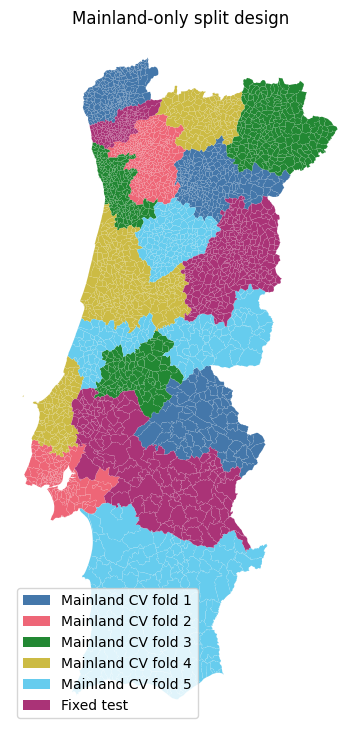

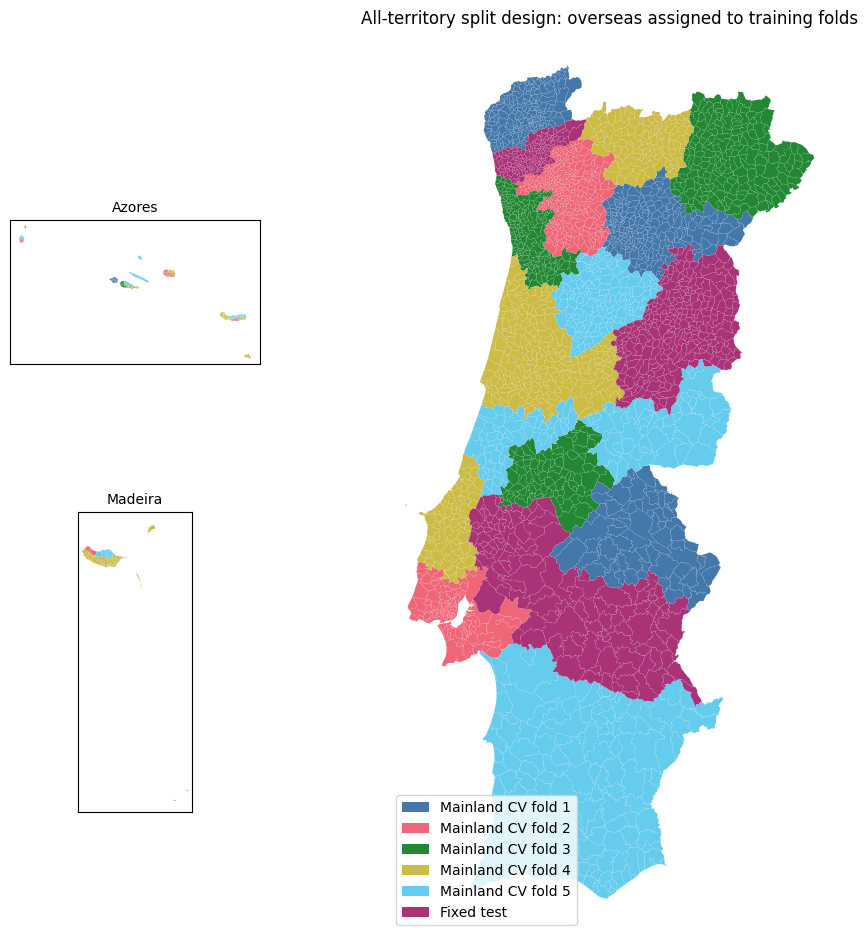

In [25]:
parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
map_base = parishes.merge(model_df[["ID_norm", "NUTS3", "municipality_id"]], on="ID_norm", how="inner")

fold_by_mainland_nuts3 = {}
for row in selected_mainland_fold_summary.itertuples(index=False):
    for nuts3 in row.validation_nuts3.split(", "):
        fold_by_mainland_nuts3[nuts3] = f"Mainland CV fold {row.fold + 1}"

fold_by_overseas_muni = {}
for row in overseas_assignments.itertuples(index=False):
    fold_by_overseas_muni[row.municipality_id] = f"Mainland CV fold {row.assigned_fold + 1}"

map_base["mainland_only_label"] = map_base["NUTS3"].map(fold_by_mainland_nuts3)
map_base.loc[map_base["NUTS3"].isin(selected_test_codes), "mainland_only_label"] = "Fixed test"

map_base["all_territories_label"] = map_base["NUTS3"].map(fold_by_mainland_nuts3)
map_base.loc[map_base["NUTS3"].isin(selected_test_codes), "all_territories_label"] = "Fixed test"
map_base.loc[map_base["NUTS3"].isin(OVERSEAS_NUTS3), "all_territories_label"] = map_base.loc[map_base["NUTS3"].isin(OVERSEAS_NUTS3), "municipality_id"].map(fold_by_overseas_muni)

split_order = [*(f"Mainland CV fold {fold}" for fold in range(1, 6)), "Fixed test"]
split_colors = {
    "Mainland CV fold 1": "#4477AA",
    "Mainland CV fold 2": "#EE6677",
    "Mainland CV fold 3": "#228833",
    "Mainland CV fold 4": "#CCBB44",
    "Mainland CV fold 5": "#66CCEE",
    "Fixed test": "#AA3377",
}


def plot_split_regions(ax, gdf, label_col):
    if gdf.empty:
        ax.set_axis_off()
        return
    plotted = False
    for label in split_order:
        part = gdf.loc[gdf[label_col].eq(label)]
        if not part.empty:
            part.plot(ax=ax, color=split_colors[label], edgecolor="white", linewidth=0.03)
            plotted = True
    if not plotted:
        gdf.plot(ax=ax, color="#D9D9D9", edgecolor="white", linewidth=0.03)
    bounds = np.asarray(gdf.total_bounds, dtype=float)
    if not np.isfinite(bounds).all():
        ax.set_axis_off()
        return
    minx, miny, maxx, maxy = bounds
    xpad = max((maxx - minx) * 0.04, 0.01)
    ypad = max((maxy - miny) * 0.04, 0.01)
    ax.set_xlim(minx - xpad, maxx + xpad)
    ax.set_ylim(miny - ypad, maxy + ypad)
    ax.set_xticks([])
    ax.set_yticks([])

mainland_map = map_base.loc[~map_base["NUTS3"].isin(OVERSEAS_NUTS3)].copy()
azores_map = map_base.loc[map_base["NUTS3"].eq("PT200")].copy()
madeira_map = map_base.loc[map_base["NUTS3"].eq("PT300")].copy()

fig, ax = plt.subplots(figsize=(7, 9))
plot_split_regions(ax, mainland_map, "mainland_only_label")
ax.set_title("Mainland-only split design")
ax.set_axis_off()
ax.legend(handles=[Patch(facecolor=split_colors[label], edgecolor="none", label=label) for label in split_order], loc="lower left", frameon=True)
plt.show()

fig = plt.figure(figsize=(10, 10))
ax_main = fig.add_axes([0.33, 0.05, 0.64, 0.90])
ax_azores = fig.add_axes([0.05, 0.54, 0.25, 0.30], frameon=True)
ax_madeira = fig.add_axes([0.05, 0.17, 0.25, 0.30], frameon=True)
plot_split_regions(ax_main, mainland_map, "all_territories_label")
plot_split_regions(ax_azores, azores_map, "all_territories_label")
plot_split_regions(ax_madeira, madeira_map, "all_territories_label")
ax_main.set_title("All-territory split design: overseas assigned to training folds")
ax_azores.set_title("Azores", fontsize=10)
ax_madeira.set_title("Madeira", fontsize=10)
ax_main.set_axis_off()
for ax in [ax_azores, ax_madeira]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
ax_main.legend(handles=[Patch(facecolor=split_colors[label], edgecolor="none", label=label) for label in split_order], loc="lower left", frameon=True)
plt.show()


## Target Distribution Diagnostics

These plots are diagnostics for the selected split design. They are not part of the optimization objective. The first figure compares each mainland CV validation fold with the total mainland distribution. The second figure compares the mainland training pool, fixed mainland test set, total mainland, and overseas territories.


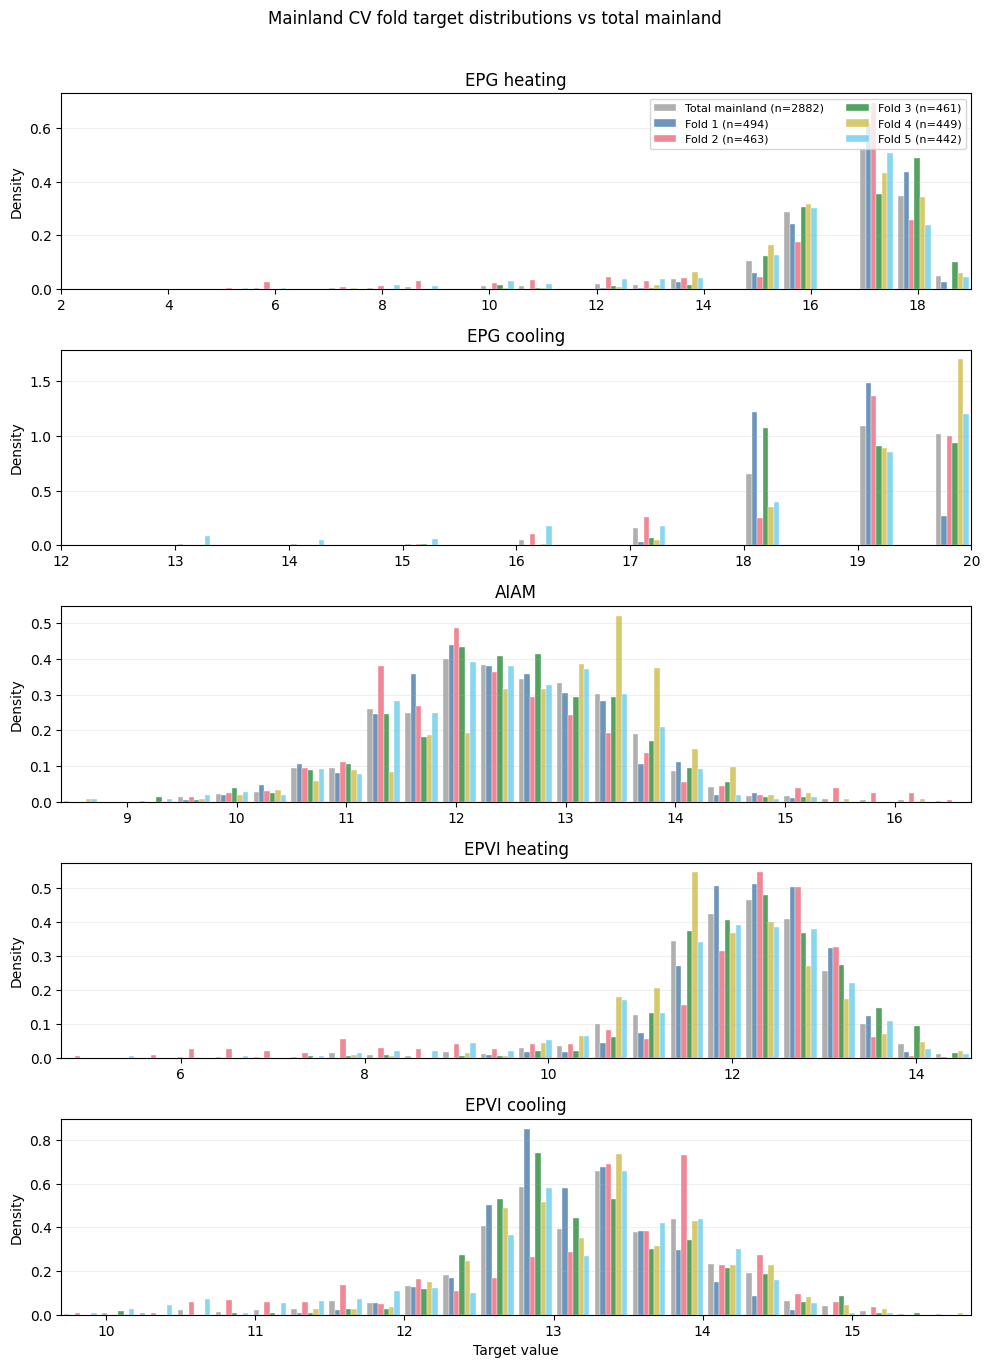

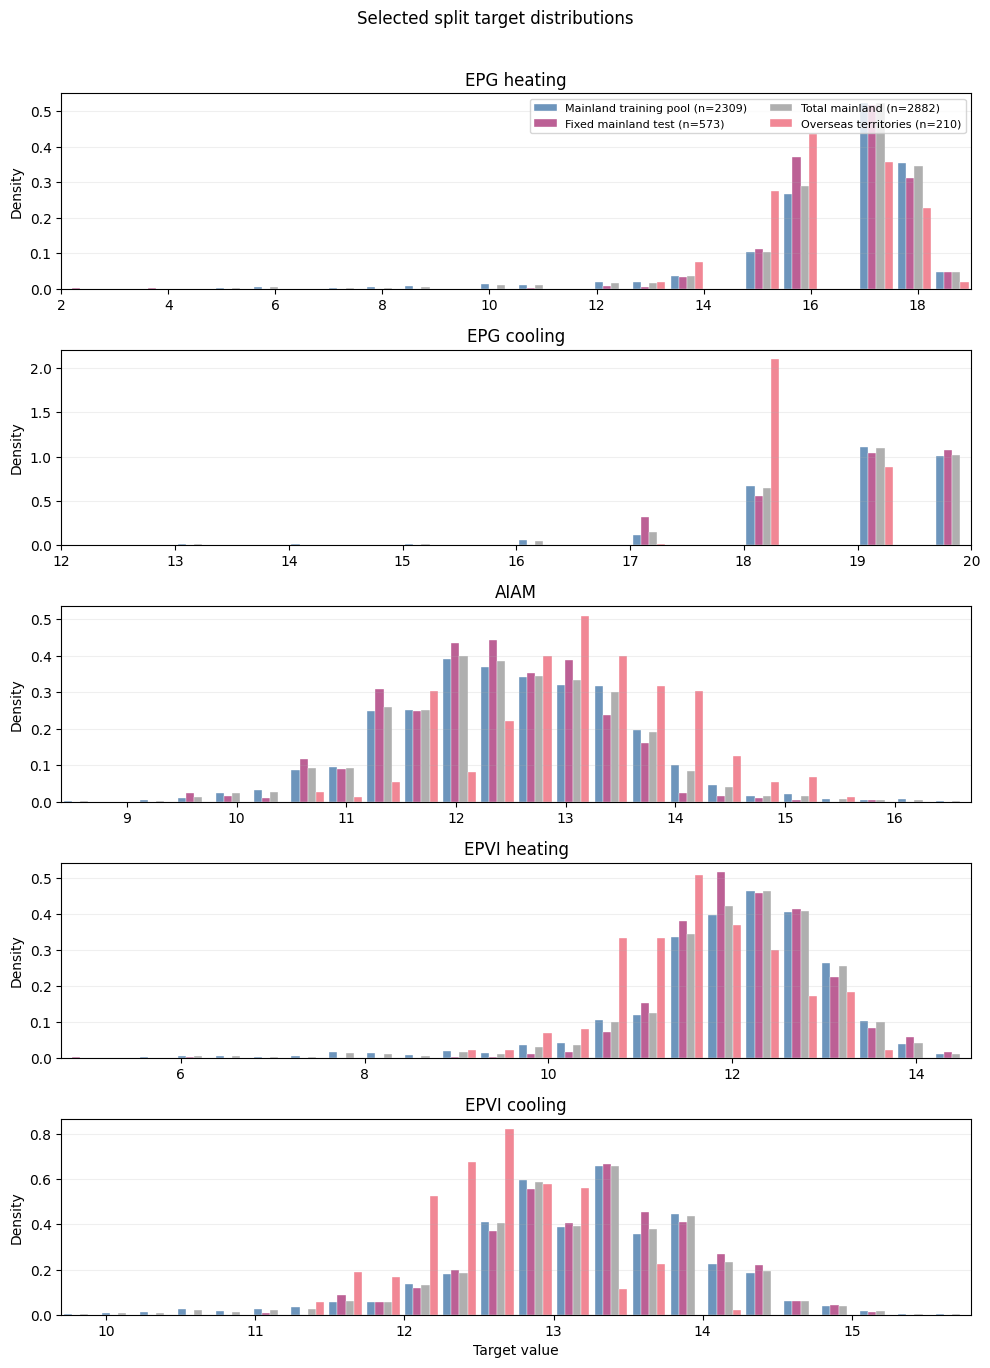

In [26]:
DIAGNOSTIC_TARGETS = list(inputs["targets"])


def finite_values(df, col):
    return pd.Series(df[col]).dropna().astype(float).to_numpy()


def target_bins(target, samples, n_bins=24):
    values = np.concatenate([finite_values(sample, target) for sample in samples if len(finite_values(sample, target))])
    if len(values) == 0:
        return np.linspace(0, 1, n_bins + 1)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    if np.isclose(vmin, vmax):
        pad = max(abs(vmin) * 0.05, 1.0)
        vmin -= pad
        vmax += pad
    return np.linspace(vmin, vmax, n_bins + 1)


def grouped_hist(ax, samples, target, bins):
    """Plot density histograms as side-by-side bars within each bin."""
    labels = [label for label, _, _ in samples]
    colors = [color for _, _, color in samples]
    bin_widths = np.diff(bins)
    n_samples = len(samples)
    group_width = bin_widths * 0.86
    bar_widths = group_width / n_samples
    left_padding = (bin_widths - group_width) / 2

    for sample_idx, (label, sample, color) in enumerate(samples):
        vals = finite_values(sample, target)
        if len(vals) == 0:
            continue
        counts, _ = np.histogram(vals, bins=bins)
        density = counts / (counts.sum() * bin_widths) if counts.sum() else counts.astype(float)
        left = bins[:-1] + left_padding + sample_idx * bar_widths
        ax.bar(
            left,
            density,
            width=bar_widths,
            align="edge",
            color=color,
            alpha=0.78,
            edgecolor="white",
            linewidth=0.35,
            label=f"{label} (n={len(sample)})",
        )

    ax.set_xlim(bins[0], bins[-1])
    ax.set_title(target)
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.2)


def plot_fold_distribution_diagnostics():
    fold_samples = []
    fold_colors = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE"]
    for color, row in zip(fold_colors, selected_mainland_fold_summary.itertuples(index=False)):
        fold_codes = code_list(row.validation_nuts3.split(", "))
        fold_df = mainland_df.loc[mainland_df["NUTS3"].isin(fold_codes)].copy()
        fold_samples.append((f"Fold {row.fold + 1}", fold_df, color))

    samples = [("Total mainland", mainland_df, "#999999"), *fold_samples]
    n_targets = len(DIAGNOSTIC_TARGETS)
    fig, axes = plt.subplots(n_targets, 1, figsize=(10, max(2.7 * n_targets, 4)), squeeze=False)

    for ax, target in zip(axes[:, 0], DIAGNOSTIC_TARGETS):
        bins = target_bins(target, [sample for _, sample, _ in samples])
        grouped_hist(ax, samples, target, bins)

    axes[-1, 0].set_xlabel("Target value")
    axes[0, 0].legend(loc="upper right", fontsize=8, ncols=2)
    fig.suptitle("Mainland CV fold target distributions vs total mainland", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_sample_distribution_diagnostics():
    samples = [
        ("Mainland training pool", selected_train_mainland_df, "#4477AA"),
        ("Fixed mainland test", selected_test_df, "#AA3377"),
        ("Total mainland", mainland_df, "#999999"),
        ("Overseas territories", overseas_df, "#EE6677"),
    ]

    n_targets = len(DIAGNOSTIC_TARGETS)
    fig, axes = plt.subplots(n_targets, 1, figsize=(10, max(2.7 * n_targets, 4)), squeeze=False)

    for ax, target in zip(axes[:, 0], DIAGNOSTIC_TARGETS):
        bins = target_bins(target, [sample for _, sample, _ in samples])
        grouped_hist(ax, samples, target, bins)

    axes[-1, 0].set_xlabel("Target value")
    axes[0, 0].legend(loc="upper right", fontsize=8, ncols=2)
    fig.suptitle("Selected split target distributions", y=1.01)
    plt.tight_layout()
    plt.show()


plot_fold_distribution_diagnostics()
plot_sample_distribution_diagnostics()


## Regenerate Test Boundary

The selected fixed test set is stored as a single dissolved GeoJSON boundary used by the mapping scripts and diagnostics notebooks. Regenerate this file only after accepting the selected test regions.


In [27]:
SPATIAL_TEST_BOUNDARY_GEOJSON = repo_data_path(PATHS, "spatial_test_set_boundary.geojson")

selected_test_ids = model_df.loc[model_df["NUTS3"].isin(selected_test_codes), "ID_norm"].drop_duplicates()
test_boundary_parts = parishes.loc[parishes["ID_norm"].isin(selected_test_ids)].copy()

if test_boundary_parts.empty:
    raise ValueError("No parish geometries matched the selected test set; boundary was not regenerated.")
missing_geometry_ids = sorted(set(selected_test_ids) - set(test_boundary_parts["ID_norm"]))
if missing_geometry_ids:
    raise ValueError(
        f"Missing geometries for {len(missing_geometry_ids)} selected test parishes; "
        f"first examples: {missing_geometry_ids[:10]}"
    )

union_geometry = (
    test_boundary_parts.geometry.union_all()
    if hasattr(test_boundary_parts.geometry, "union_all")
    else test_boundary_parts.geometry.unary_union
)

test_boundary = gpd.GeoDataFrame(
    {
        "split_role": ["fixed_test"],
        "test_nuts3": [joined_codes(selected_test_codes)],
        "n_parishes": [len(test_boundary_parts)],
    },
    geometry=[union_geometry],
    crs=test_boundary_parts.crs,
)
SPATIAL_TEST_BOUNDARY_GEOJSON.parent.mkdir(parents=True, exist_ok=True)
test_boundary.to_file(SPATIAL_TEST_BOUNDARY_GEOJSON, driver="GeoJSON")
print(f"Regenerated {SPATIAL_TEST_BOUNDARY_GEOJSON}")
print(f"Selected test regions: {joined_codes(selected_test_codes)}")
print(f"Parish geometries dissolved: {len(test_boundary_parts)}")
display(test_boundary.drop(columns="geometry"))


Regenerated E:\git_projects\energy_poverty_from_space\data\spatial_test_set_boundary.geojson
Selected test regions: PT112, PT16J, PT185, PT187
Parish geometries dissolved: 573


,split_role,test_nuts3,n_parishes
0,fixed_test,"PT112, PT16J, PT185, PT187",573


## Reporting Note

The selected fixed test set is a pre-defined spatial evaluation set, not a model-selection fold. The mainland-only and all-territory workflows should use the same fixed mainland test set for comparability. In the all-territory workflow, overseas parishes are added only to the training/CV folds through municipality-level assignment.

If this notebook selects a test set different from `pipeline.3_epvi_prediction.utils.DEFAULT_TEST_NUTS3`, update that constant only after accepting the design and regenerating `data/spatial_test_set_boundary.geojson`.
